# 📊 Notebook 02: Análise de Matrículas por Gênero
## Análise de Desigualdades de Gênero na Educação Básica Brasileira

**Autora:** Sara - Mestra em Educação

### 📋 Objetivos deste notebook:
1. Analisar a distribuição de gênero na educação básica
2. Comparar proporções por rede de ensino
3. Identificar disparidades regionais
4. Analisar diferenças urbano vs rural

---

⚠️ **NOTA IMPORTANTE:** Os dados do Censo 2025 só possuem informações de gênero para o **TOTAL** da educação básica, não por etapa de ensino individual.

In [5]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Adicionar diretório de scripts ao path
import sys
sys.path.append('../scripts')

# Importar configurações
from config import CORES, GRAPHICS_PATH, PROCESSED_DATA_PATH

# Configurações de visualização
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


## 1️⃣ Carregar Dados Processados

In [6]:
# Carregar dados processados
df = pd.read_csv(PROCESSED_DATA_PATH + 'escolas_analise.csv', encoding='utf-8')

print(f"✅ Dados carregados: {len(df):,} escolas")
print(f"\n📋 Colunas disponíveis:")
print(df.columns.tolist())

# Verificar se colunas de gênero existem
cols_genero = [c for c in df.columns if 'FEM' in c or 'MASC' in c]
print(f"\n📊 Colunas de gênero: {cols_genero}")

✅ Dados carregados: 180,540 escolas

📋 Colunas disponíveis:
['NO_REGIAO', 'CO_REGIAO', 'SG_UF', 'CO_UF', 'NO_MUNICIPIO', 'CO_MUNICIPIO', 'NO_ENTIDADE', 'CO_ENTIDADE', 'TP_DEPENDENCIA', 'TP_LOCALIZACAO', 'TP_SITUACAO_FUNCIONAMENTO', 'QT_MAT_BAS', 'QT_MAT_INF_CRE', 'QT_MAT_INF_PRE', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED', 'QT_MAT_EJA', 'QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC', 'QT_GEST_BAS', 'QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC', 'QT_GEST_BAS_DIRETOR', 'QT_GEST_BAS_OUTRO', 'PORC_MENINAS', 'PORC_GESTORAS']

📊 Colunas de gênero: ['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC', 'QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC']


## 2️⃣ Panorama Nacional de Gênero

In [7]:
# Calcular totais nacionais
print("📊 Panorama Nacional - Educação Básica:")
print("=" * 50)

total_meninas = df['QT_MAT_BAS_FEM'].sum()
total_meninos = df['QT_MAT_BAS_MASC'].sum()
total_geral = total_meninas + total_meninos

print(f"\n👩 Meninas: {total_meninas:,.0f} ({total_meninas/total_geral*100:.1f}%)")
print(f"👦 Meninos: {total_meninos:,.0f} ({total_meninos/total_geral*100:.1f}%)")
print(f"📚 Total: {total_geral:,.0f}")

print(f"\n📊 Diferença absoluta: {abs(total_meninas - total_meninos):,.0f} alunos")
print(f"📊 Diferença percentual: {abs(total_meninas/total_geral*100 - 50):.2f} pontos percentuais")

📊 Panorama Nacional - Educação Básica:

👩 Meninas: 22,735,128 (49.4%)
👦 Meninos: 23,283,252 (50.6%)
📚 Total: 46,018,380

📊 Diferença absoluta: 548,124 alunos
📊 Diferença percentual: 0.60 pontos percentuais


In [ ]:
# Gráfico de pizza - Distribuição Nacional
fig, ax = plt.subplots(figsize=(10, 8))

sizes = [total_meninas, total_meninos]
labels = [f'Meninas\n{total_meninas:,.0f}\n({total_meninas/total_geral*100:.1f}%)',
         f'Meninos\n{total_meninos:,.0f}\n({total_meninos/total_geral*100:.1f}%)']
colors = [CORES['feminino'], CORES['masculino']]

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='', startangle=90,
                                   textprops={'fontsize': 13, 'fontweight': 'bold'})

ax.set_title('Distribuição de Gênero na Educação Básica\nBrasil 2025',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '01_distribuicao_nacional.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: 01_distribuicao_nacional.png")
plt.show()

print("\n📝 INTERPRETAÇÃO:")
print("=" * 60)
if abs(total_meninas/total_geral*100 - 50) < 1:
    print("✅ Há praticamente paridade de gênero na educação básica brasileira!")
elif total_meninas > total_meninos:
    print(f"👩 As meninas são maioria em {total_meninas/total_geral*100:.1f}% das matrículas.")
else:
    print(f"👦 Os meninos são maioria em {total_meninos/total_geral*100:.1f}% das matrículas.")

# TESTE ESTATÍSTICO - Qui-quadrado
from scipy import stats

print("\n📊 TESTE ESTATÍSTICO (Qui-quadrado):")
print("=" * 60)
total_esperado = (total_meninas + total_meninos) / 2
chi2, p_value = stats.chisquare([total_meninas, total_meninos], 
                                [total_esperado, total_esperado])

print(f"   • Estatística qui-quadrado: {chi2:.2f}")
print(f"   • p-valor: {p_value:.4f}")
print(f"   • Nível de significância: α = 0.05")

if p_value < 0.05:
    print("\n   ✅ RESULTADO: A diferença é ESTATISTICAMENTE SIGNIFICATIVA")
    print(f"   (p-valor {p_value:.4f} < 0.05)")
else:
    print("\n   ❌ RESULTADO: A diferença NÃO é estatisticamente significativa")
    print(f"   (p-valor {p_value:.4f} ≥ 0.05)")
    
print("\n💡 INTERPRETAÇÃO:")
if p_value < 0.001:
    print("   A diferença observada é altamente significativa do ponto de vista estatístico.")
    print("   No entanto, a magnitude da diferença é pequena (<1%),")
    print("   o que limita sua relevância prática em termos de políticas públicas.")
elif p_value < 0.05:
    print("   A diferença é estatisticamente significativa, mas próxima da paridade.")
    print("   Sugere-se investigar causas contextuais dessa pequena disparidade.")
else:
    print("   Não há evidências estatísticas de diferença significativa.")
    print("   A educação básica brasileira apresenta paridade de gênero.")

# TESTE DE NORMALIDADE - Shapiro-Wilk
print("\n📊 TESTE DE NORMALIDADE (Shapiro-Wilk):")
print("=" * 60)

# Amostra devido ao tamanho grande do dataset
amostra = df['PORC_MENINAS'].dropna().sample(min(5000, len(df)), random_state=42)
stat, p_norm = stats.shapiro(amostra)

print(f"   • Estatística Shapiro-Wilk: {stat:.4f}")
print(f"   • p-valor: {p_norm:.4f}")
print(f"   • Tamanho da amostra: {len(amostra):,} escolas")

if p_norm > 0.05:
    print("\n   ✅ RESULTADO: Distribuição NORMAL")
    print("   Os dados seguem uma distribuição normal.")
else:
    print("\n   ❌ RESULTADO: Distribuição NÃO NORMAL")
    print("   (Isso é esperado para proporções distribuídas entre 0-100%)")
    
print("\n💡 INTERPRETAÇÃO:")
if p_norm < 0.05:
    print("   A não-normalidade é esperada para dados de proporção, pois são")
    print("   limitados entre 0% e 100%. Por isso, usamos testes não-paramétricos")
    print("   (como o qui-quadrado) que não assumem normalidade dos dados.")
    print("\n   Visualização: A maioria das escolas concentra-se próximo à")
    print(f"   média nacional ({df['PORC_MENINAS'].mean():.1f}%), com algumas escolas")
    print("   tendo proporções mais extremas (próximas de 0% ou 100%).")

## 3️⃣ Análise por Rede de Ensino

In [9]:
# Calcular porcentagem de meninas por rede
print("📊 Proporção de Meninas por Rede de Ensino:")
print("=" * 50)

df_rede = df.groupby('TP_DEPENDENCIA')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_rede['Total'] = df_rede['QT_MAT_BAS_FEM'] + df_rede['QT_MAT_BAS_MASC']
df_rede['% Meninas'] = (df_rede['QT_MAT_BAS_FEM'] / df_rede['Total']) * 100
df_rede['% Meninos'] = (df_rede['QT_MAT_BAS_MASC'] / df_rede['Total']) * 100
df_rede = df_rede.sort_values('% Meninas', ascending=False)

print(df_rede[['Total', '% Meninas', '% Meninos']].to_string())

print("\n🔍 Insights:")
for rede in df_rede.index:
    pct = df_rede.loc[rede, '% Meninas']
    if pct > 51:
        print(f"   • {rede}: {pct:.1f}% meninas (ACIMA da paridade)")
    elif pct < 49:
        print(f"   • {rede}: {pct:.1f}% meninas (ABAIXO da paridade)")
    else:
        print(f"   • {rede}: {pct:.1f}% meninas (quase paridade)")

📊 Proporção de Meninas por Rede de Ensino:
                     Total  % Meninas  % Meninos
TP_DEPENDENCIA                                  
Federal           383526.0  51.137863  48.862137
Privada          9245384.0  50.565590  49.434410
Estadual        13330302.0  49.896679  50.103321
Municipal       23059168.0  48.625518  51.374482

🔍 Insights:
   • Federal: 51.1% meninas (ACIMA da paridade)
   • Privada: 50.6% meninas (quase paridade)
   • Estadual: 49.9% meninas (quase paridade)
   • Municipal: 48.6% meninas (ABAIXO da paridade)


💾 Gráfico salvo: 02_genero_por_rede.png


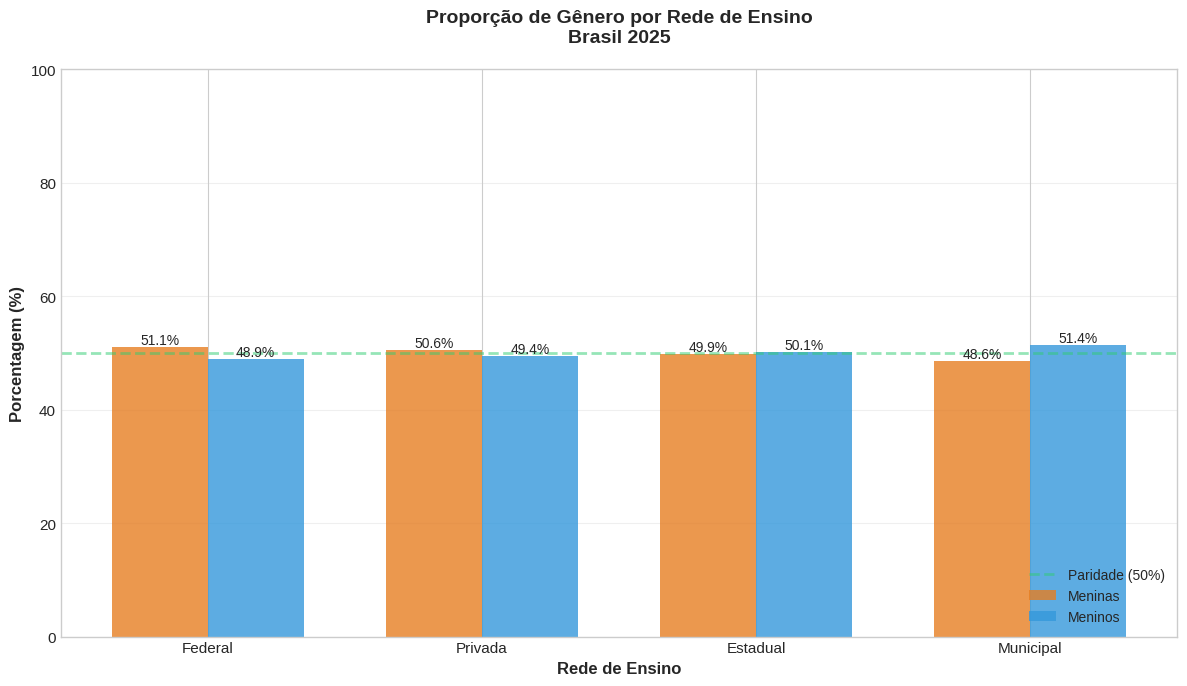

In [10]:
# Gráfico por rede
fig, ax = plt.subplots(figsize=(12, 7))

redes = df_rede.index.tolist()
x = np.arange(len(redes))
width = 0.35

bars1 = ax.bar(x - width/2, df_rede['% Meninas'], width, label='Meninas',
               color=CORES['feminino'], alpha=0.8)
bars2 = ax.bar(x + width/2, df_rede['% Meninos'], width, label='Meninos',
               color=CORES['masculino'], alpha=0.8)

ax.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5, label='Paridade (50%)')

ax.set_xlabel('Rede de Ensino', fontsize=12, fontweight='bold')
ax.set_ylabel('Porcentagem (%)', fontsize=12, fontweight='bold')
ax.set_title('Proporção de Gênero por Rede de Ensino\nBrasil 2025',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(redes)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Adicionar valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '02_genero_por_rede.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: 02_genero_por_rede.png")
plt.show()

## 4️⃣ Análise Regional

In [11]:
# Calcular porcentagem de meninas por região
print("📊 Proporção de Meninas por Região:")
print("=" * 50)

df_regiao = df.groupby('NO_REGIAO')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_regiao['Total'] = df_regiao['QT_MAT_BAS_FEM'] + df_regiao['QT_MAT_BAS_MASC']
df_regiao['% Meninas'] = (df_regiao['QT_MAT_BAS_FEM'] / df_regiao['Total']) * 100
df_regiao = df_regiao.sort_values('% Meninas', ascending=False)

print(df_regiao[['Total', '% Meninas']].to_string())

print("\n🏆 Região com maior proporção de meninas:")
max_reg = df_regiao['% Meninas'].idxmax()
max_pct = df_regiao['% Meninas'].max()
print(f"   {max_reg}: {max_pct:.1f}%")

print("\n📉 Região com menor proporção de meninas:")
min_reg = df_regiao['% Meninas'].idxmin()
min_pct = df_regiao['% Meninas'].min()
print(f"   {min_reg}: {min_pct:.1f}%")

print(f"\n📊 Variação regional: {max_pct - min_pct:.1f} pontos percentuais")

📊 Proporção de Meninas por Região:
                   Total  % Meninas
NO_REGIAO                          
Sudeste       18007935.0  49.523124
Nordeste      13225818.0  49.359593
Centro-Oeste   3710835.0  49.331080
Sul            6397634.0  49.310745
Norte          4676158.0  49.260739

🏆 Região com maior proporção de meninas:
   Sudeste: 49.5%

📉 Região com menor proporção de meninas:
   Norte: 49.3%

📊 Variação regional: 0.3 pontos percentuais


💾 Gráfico salvo: 03_meninas_por_regiao.png


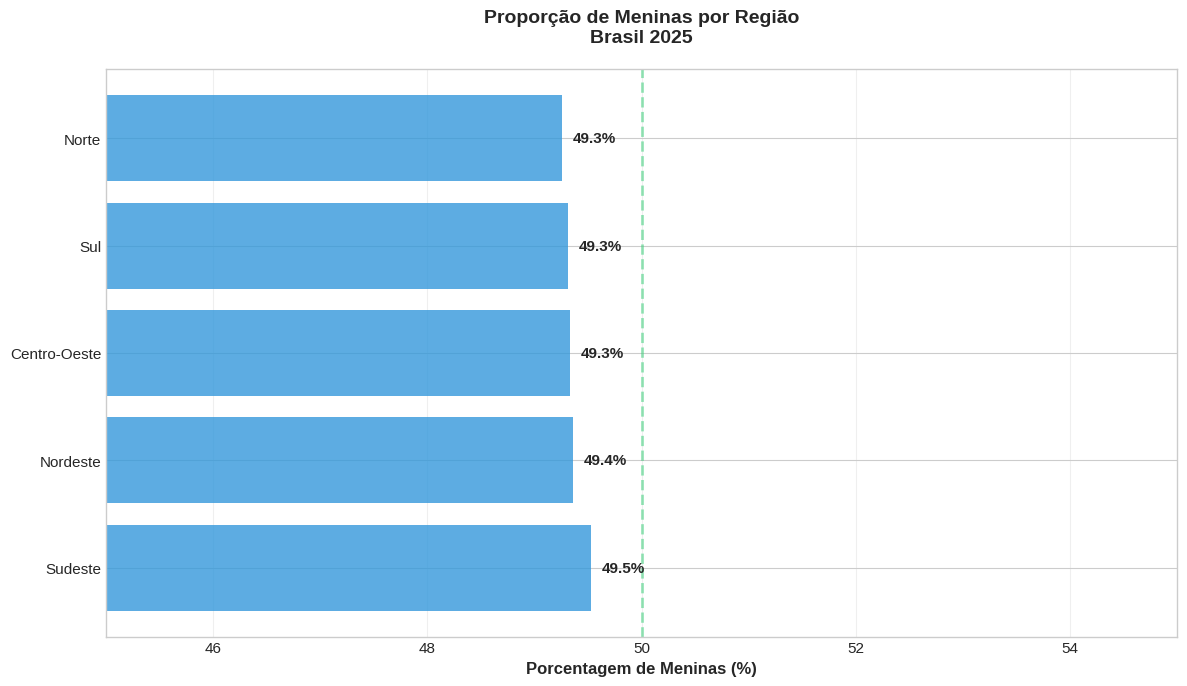

In [12]:
# Gráfico regional
fig, ax = plt.subplots(figsize=(12, 7))

regioes = df_regiao.index.tolist()
y_pos = np.arange(len(regioes))

bars = ax.barh(y_pos, df_regiao['% Meninas'],
           color=[CORES['feminino'] if x >= 50 else CORES['masculino']
                  for x in df_regiao['% Meninas']], alpha=0.8)

ax.axvline(x=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5)

ax.set_xlabel('Porcentagem de Meninas (%)', fontsize=12, fontweight='bold')
ax.set_title('Proporção de Meninas por Região\nBrasil 2025',
             fontsize=14, fontweight='bold', pad=20)
ax.set_yticks(y_pos)
ax.set_yticklabels(regioes)
ax.set_xlim(45, 55)
ax.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, (bar, pct) in enumerate(zip(bars, df_regiao['% Meninas'])):
    ax.text(pct + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '03_meninas_por_regiao.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: 03_meninas_por_regiao.png")
plt.show()

## 5️⃣ Análise Urbano vs Rural

In [13]:
# Comparar urbano vs rural
print("📊 Proporção de Meninas: Urbano vs Rural")
print("=" * 50)

df_local = df.groupby('TP_LOCALIZACAO')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_local['Total'] = df_local['QT_MAT_BAS_FEM'] + df_local['QT_MAT_BAS_MASC']
df_local['% Meninas'] = (df_local['QT_MAT_BAS_FEM'] / df_local['Total']) * 100

print(df_local[['Total', '% Meninas']].to_string())

print("\n🔍 Insights:")
diferenca = abs(df_local.loc['Urbana', '% Meninas'] - df_local.loc['Rural', '% Meninas'])
print(f"   Diferença urbano/rural: {diferenca:.1f} pontos percentuais")

if diferenca < 1:
    print("   ✅ Não há diferença significativa entre urbano e rural")
else:
    print(f"   ⚠️ Há uma diferença de {diferenca:.1f} pp entre áreas urbanas e rurais")

📊 Proporção de Meninas: Urbano vs Rural
                     Total  % Meninas
TP_LOCALIZACAO                       
Rural            5147214.0  48.341899
Urbana          40871166.0  49.538266

🔍 Insights:
   Diferença urbano/rural: 1.2 pontos percentuais
   ⚠️ Há uma diferença de 1.2 pp entre áreas urbanas e rurais


## 6️⃣ Estados Extremos

In [ ]:
# Estados com maior e menor proporção de meninas
print("📊 Estados: Maior e Menor Proporção de Meninas")
print("=" * 50)

df_uf = df.groupby('SG_UF')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_uf['Total'] = df_uf['QT_MAT_BAS_FEM'] + df_uf['QT_MAT_BAS_MASC']
df_uf['% Meninas'] = (df_uf['QT_MAT_BAS_FEM'] / df_uf['Total']) * 100
# CORREÇÃO: Filtro reduzido de 10000 para 1000 para não excluir estados pequenos
df_uf = df_uf[df_uf['Total'] > 1000]

top_10 = df_uf.nlargest(10, '% Meninas')
bottom_10 = df_uf.nsmallest(10, '% Meninas')

print("\n🏆 TOP 10 - Maior proporção de meninas:")
for uf, row in top_10.iterrows():
    print(f"   {uf}: {row['% Meninas']:.1f}% ({row['Total']:,.0f} alunos)")

print("\n📉 BOTTOM 10 - Menor proporção de meninas:")
for uf, row in bottom_10.iterrows():
    print(f"   {uf}: {row['% Meninas']:.1f}% ({row['Total']:,.0f} alunos)")

print(f"\n📊 Total de estados analisados: {len(df_uf)}")

## ✅ Resumo do Notebook

### 📊 Análises Realizadas:
- ✅ Panorama nacional de gênero
- ✅ Distribuição por rede de ensino
- ✅ Disparidades regionais
- ✅ Análise urbano vs rural
- ✅ Estados extremos

### 📁 Gráficos Gerados:
- `01_distribuicao_nacional.png`
- `02_genero_por_rede.png`
- `03_meninas_por_regiao.png`

### 🔍 Insights Principais:
- Os dados mostram praticamente paridade de gênero na educação básica
- Existem variações interessantes por rede e região

### 🚀 Próximos Passos:
Ir para **03_analise_gestao_escolar.ipynb**

---

✨ **Notebook 02 concluído!** ✨